# 06 · Naive Bayes and Unsupervised Learning

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/06-naive-bayes-and-unsupervised-learning/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Bayes' rule by hand

In [1]:
# 100 emails: 40 spam and 60 normal
p_spam = 40 / 100                  # prior: how common spam is
p_not_spam = 60 / 100

p_free_given_spam = 28 / 40        # "free" is in 28 of the 40 spam emails...
p_free_given_not_spam = 6 / 60     # ...and in 6 of the 60 normal ones

# evidence: how common "free" is overall, in spam or not
p_free = p_free_given_spam * p_spam + p_free_given_not_spam * p_not_spam

# Bayes' rule: flip P(free | spam) into P(spam | free)
p_spam_given_free = p_free_given_spam * p_spam / p_free

print(f"P(free)        = {p_free:.2f}")
print(f"P(spam | free) = {p_spam_given_free:.4f}")
# P(free)        = 0.34
# P(spam | free) = 0.8235

P(free)        = 0.34
P(spam | free) = 0.8235


- One word moved the belief from 40% (the prior) to about 82% (the posterior).
- It's the same answer the diagram gets by counting: 28 of the 34 emails with "free" are spam, and 28 / 34 = 0.8235.
- `p_free` adds up both ways an email can contain "free": spam that says it, plus normal email that says it.

### Step 2 · Turn messages into word counts

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "WINNER! Claim your free prize now",
    "Free cash bonus, click here to claim",
    "You won a free vacation, claim it today",
    "Urgent: claim your cash prize before midnight",
    "Congratulations, lucky winner! Click for your free gift",
    "Limited offer: earn cash from home, click now",
    "Are you free for lunch tomorrow?",
    "The meeting moved to 3pm, agenda attached",
    "Can you send me the project report?",
    "Mom says dinner is at 7 tonight",
    "Thanks for the notes from today's meeting",
    "Let's review the report before the meeting",
    "Happy birthday! See you at dinner",
    "Running late, start the meeting without me",
    "Your package was delivered this morning",
]
labels = np.array(["spam"] * 6 + ["not spam"] * 9)

vectorizer = CountVectorizer(stop_words="english")   # skip filler words like "the" and "you"
X_train = vectorizer.fit_transform(texts)            # learn the vocabulary, then count
words = vectorizer.get_feature_names_out()

print("Messages x words:", X_train.shape)
table = pd.DataFrame(X_train.toarray(), columns=words, index=labels)
print(table[["claim", "free", "prize", "meeting", "lunch"]].iloc[[0, 1, 6, 7]])
# Messages x words: (15, 45)
#           claim  free  prize  meeting  lunch
# spam          1     1      1        0      0
# spam          1     1      0        0      0
# not spam      0     1      0        0      1
# not spam      0     0      0        1      0

Messages x words: (15, 45)
          claim  free  prize  meeting  lunch
spam          1     1      1        0      0
spam          1     1      0        0      0
not spam      0     1      0        0      1
not spam      0     0      0        1      0


- 15 messages and 45 different words. Each message is now one row of counts, and the word order is gone: that's the bag of words.
- `stop_words="english"` drops very common filler words ("the", "you", "is" and so on), so the counts focus on words that carry meaning.
- "free" shows up in normal email too ("Are you free for lunch tomorrow?"). It's evidence, not proof.
- `X_train` is a **sparse matrix**: it stores only the non-zero counts, because most words are missing from most messages. `.toarray()` turns it into a normal table for printing.

### Step 3 · Train the filter and classify new messages

In [3]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()          # alpha=1.0 by default: smoothing is on (Step 5)
model.fit(X_train, labels)

new_texts = [
    "Claim your free cash prize now",
    "Lunch tomorrow before the meeting?",
    "Free pizza after the meeting",
]
X_new = vectorizer.transform(new_texts)      # transform, never fit_transform, on new text

print(model.classes_)
for text, label, p in zip(new_texts, model.predict(X_new), model.predict_proba(X_new)[:, 1]):
    print(f"{label:<8}  P(spam) = {p:.2f}   {text}")
# ['not spam' 'spam']
# spam      P(spam) = 0.99   Claim your free cash prize now
# not spam  P(spam) = 0.03   Lunch tomorrow before the meeting?
# not spam  P(spam) = 0.26   Free pizza after the meeting

['not spam' 'spam']
spam      P(spam) = 0.99   Claim your free cash prize now
not spam  P(spam) = 0.03   Lunch tomorrow before the meeting?
not spam  P(spam) = 0.26   Free pizza after the meeting


- `predict_proba` returns one column per class, in the order of `model.classes_`, so `[:, 1]` is P(spam).
- The third message contains "free", but "meeting" pulls harder the other way. No single word decides; every word gets a vote.
- "pizza" never appeared in training, so it isn't in the vocabulary and is simply ignored.

### Step 4 · See which words weigh the most

In [4]:
p_word = np.exp(model.feature_log_prob_)     # P(word | class): row 0 = not spam, row 1 = spam
spamminess = pd.Series(p_word[1] / p_word[0], index=words)

print("Toward spam:  ", spamminess.nlargest(5).round(1).to_dict())
print("Toward normal:", (1 / spamminess).nlargest(5).round(1).to_dict())
# Toward spam:   {'claim': 5.1, 'cash': 4.1, 'click': 4.1, 'prize': 3.1, 'winner': 3.1}
# Toward normal: {'meeting': 4.9, 'dinner': 2.9, 'report': 2.9, '3pm': 1.9, 'agenda': 1.9}

Toward spam:   {'claim': 5.1, 'cash': 4.1, 'click': 4.1, 'prize': 3.1, 'winner': 3.1}
Toward normal: {'meeting': 4.9, 'dinner': 2.9, 'report': 2.9, '3pm': 1.9, 'agenda': 1.9}


- These are the nudges from the diagram at the top: "claim" is about 5 times more likely in spam than in normal email, so it pushes hard toward spam.
- scikit-learn stores the logarithm of each probability in `feature_log_prob_`, and `np.exp` turns them back into plain probabilities.
- Nobody gave the model a list of spam words. It learned all of this from 15 messages, just by counting.

### Step 5 · Smoothing: why a missing word can't count as zero

In [5]:
counts = X_train.toarray()
spam_counts = counts[labels == "spam"].sum(axis=0)       # times each word appears in spam
V = len(words)                                           # vocabulary size: 45

raw = spam_counts / spam_counts.sum()                    # plain fractions
smoothed = (spam_counts + 1) / (spam_counts.sum() + V)   # add-one smoothing

msg = "Claim your free prize at the meeting"
tokens = vectorizer.build_analyzer()(msg)                # the words the model will see
idx = [vectorizer.vocabulary_[t] for t in tokens]

print(tokens)
print("raw:     ", raw[idx].round(3), f"-> product {raw[idx].prod():.7f}")
print("smoothed:", smoothed[idx].round(3), f"-> product {smoothed[idx].prod():.7f}")
print("Same as scikit-learn:", np.allclose(smoothed, p_word[1]))
print("P(spam) =", model.predict_proba(vectorizer.transform([msg]))[0, 1].round(2))
# ['claim', 'free', 'prize', 'meeting']
# raw:      [0.129 0.129 0.065 0.   ] -> product 0.0000000
# smoothed: [0.066 0.066 0.039 0.013] -> product 0.0000022
# Same as scikit-learn: True
# P(spam) = 0.85

['claim', 'free', 'prize', 'meeting']
raw:      [0.129 0.129 0.065 0.   ] -> product 0.0000000
smoothed: [0.066 0.066 0.039 0.013] -> product 0.0000022
Same as scikit-learn: True
P(spam) = 0.85


- Without smoothing, "meeting" gets exactly 0, and one 0 wipes out the product: this message could never be called spam, whatever else it said.
- Add-one smoothing gives "meeting" 1/76 instead. That's small, but the other words still count.
- `np.allclose` confirms that this is exactly what `MultinomialNB(alpha=1.0)` learned: `alpha` is the "+1".
- With smoothing on, the model sees through the trick: P(spam) = 0.85.

### Step 6 · Numbers instead of words: GaussianNB

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

iris = load_iris()
X_iris, y_iris = iris.data, iris.target      # 150 flowers, 4 measurements in cm, 3 species

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
print("Test accuracy:", round(gnb.score(X_te, y_te), 3))
# Test accuracy: 0.911

Test accuracy: 0.911


- The iris dataset ships with scikit-learn: 150 iris flowers from 3 species, each described by 4 measurements in centimeters (sepal length and width, petal length and width).
- Same Bayes' rule, same naive shortcut, same `fit` and `score`. Only the per-feature model changes: a bell curve for each measurement and each species, instead of word counts.
- The measurements are far from independent (long petals are also wide petals), and the model still gets about 9 in 10 test flowers right.
- `stratify=y_iris` keeps the same mix of species in the training and test sets.

### Step 7 · Hide the labels: a first taste of clustering

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
groups = kmeans.fit_predict(X_iris)          # only X: the species are never shown

species = iris.target_names[y_iris]          # the real names, used only to check afterwards
print(pd.crosstab(species, groups, rownames=["species"], colnames=["group"]))
# group        0   1   2
# species
# setosa       0  50   0
# versicolor  48   0   2
# virginica   14   0  36

group        0   1   2
species               
setosa       0  50   0
versicolor  48   0   2
virginica   14   0  36


- Look at the call: `fit_predict(X_iris)`, with no `y`. K-Means was only asked for 3 groups; it never saw a species name.
- It put all 50 setosa flowers in one group and mostly separated the other two species, which overlap in real life.
- Group numbers are just names: group 1 isn't "setosa" to the model, and on another computer the numbers may come out shuffled. Naming the groups is your job.
- The species are used only *after* clustering, to check the result. How K-Means works, and how to choose the number of groups, is [lesson 07](../07-clustering-and-pca/README.md).

### See it

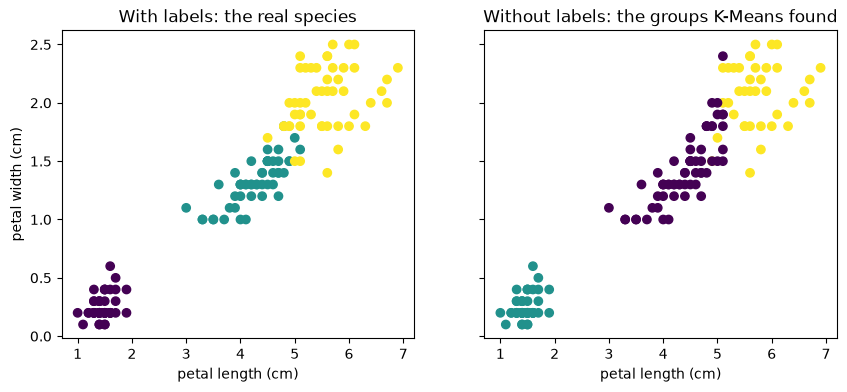

In [8]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
left.scatter(X_iris[:, 2], X_iris[:, 3], c=y_iris)
left.set_title("With labels: the real species")
right.scatter(X_iris[:, 2], X_iris[:, 3], c=groups)
right.set_title("Without labels: the groups K-Means found")
for ax in (left, right):
    ax.set_xlabel("petal length (cm)")
left.set_ylabel("petal width (cm)")
plt.show()

- The colors don't line up between the two plots, because K-Means numbered its groups in its own order. Only *which* flowers end up together matters, not the numbers.

### Bonus · Naive Bayes by hand in a few lines of NumPy

In [9]:
msg_counts = vectorizer.transform([msg]).toarray()[0]

log_scores = []
for c in model.classes_:                                     # "not spam", then "spam"
    rows = counts[labels == c]
    prior = len(rows) / len(counts)                          # P(class)
    p_words = (rows.sum(axis=0) + 1) / (rows.sum() + V)      # P(word | class), smoothed
    log_scores.append(np.log(prior) + np.sum(msg_counts * np.log(p_words)))

scores = np.exp(np.array(log_scores) - max(log_scores))      # undo the logs, safely
print("By hand:     ", (scores / scores.sum()).round(4))
print("scikit-learn:", model.predict_proba(vectorizer.transform([msg]))[0].round(4))
# By hand:      [0.1527 0.8473]
# scikit-learn: [0.1527 0.8473]

By hand:      [0.1527 0.8473]
scikit-learn: [0.1527 0.8473]


- That's the whole algorithm: a prior for each class, smoothed word probabilities for each class, and a product.
- Multiplying hundreds of small probabilities underflows to 0.0 on a computer, so real implementations add up **logarithms** instead, since log(a × b) = log(a) + log(b). Subtracting the largest log score before `np.exp` keeps the numbers in a safe range.
- Change `msg` in Step 5, rerun both cells, and the two lines will still match.